<a href="https://colab.research.google.com/github/jellybbie/study/blob/project2/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel('/content/rawdata-gray03.xlsx')

In [2]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Treatment,repeat1,repeat2,repeat3,repeat4,repeat5
0,Spray TAU-3,65,49,57,69,67
1,Spray BTH,6,9,7,10,5
2,Spray MgSO4,59,85,89,54,79
3,Drench TAU-3,46,72,85,80,67
4,Drench BTH,10,24,40,9,3


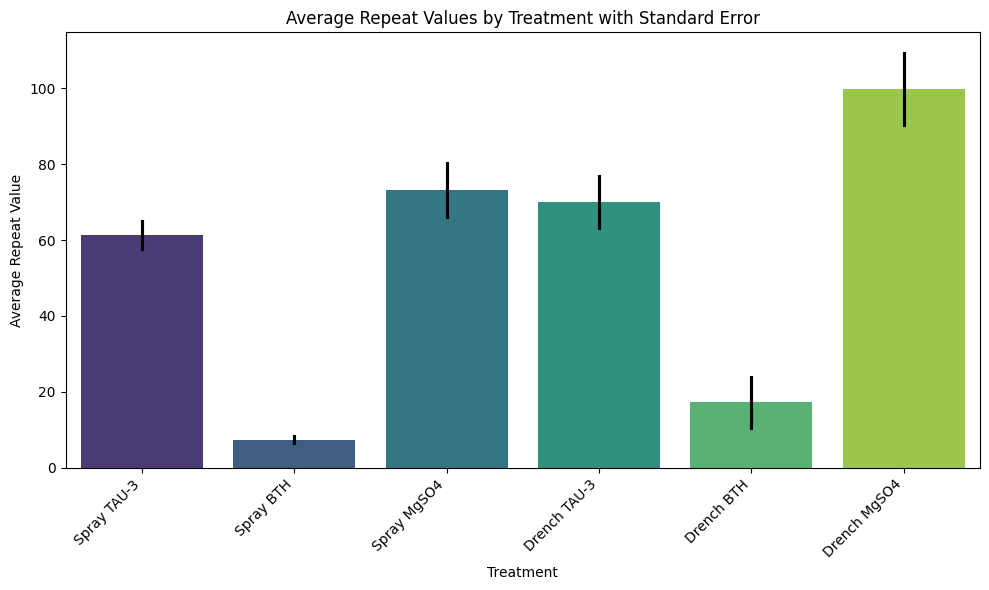

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for proper error bar calculation
df_melted = df.melt(id_vars=['Treatment'], value_vars=['repeat1', 'repeat2', 'repeat3', 'repeat4', 'repeat5'],
                   var_name='Repeat_Number', value_name='Repeat_Value')

# Create the bar plot with error bars (standard error) and black error bar color
plt.figure(figsize=(10, 6))
sns.barplot(x='Treatment', y='Repeat_Value', data=df_melted, palette='viridis',
            errorbar='se', # Add standard error as error bars
            hue='Treatment', legend=False,
            err_kws={'color': 'black'}) # Set error bar color to black
plt.title('Average Repeat Values by Treatment with Standard Error')
plt.xlabel('Treatment')
plt.ylabel('Average Repeat Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Perform One-Way ANOVA
# Convert 'Treatment' to categorical type if not already
df_melted['Treatment'] = df_melted['Treatment'].astype('category')

# Create a list of arrays, one for each treatment group
treatment_groups = [df_melted['Repeat_Value'][df_melted['Treatment'] == t] for t in df_melted['Treatment'].unique()]

f_statistic, p_value = stats.f_oneway(*treatment_groups)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA P-value: {p_value:.3f}")

# Perform Tukey's HSD post-hoc test if ANOVA is significant
if p_value < 0.05:
    print("\nANOVA is significant (p < 0.05). Performing Tukey's HSD post-hoc test...")
    tukey_results = pairwise_tukeyhsd(endog=df_melted['Repeat_Value'], groups=df_melted['Treatment'], alpha=0.05)
    print(tukey_results)

    # Generate alphabetical labels for groups that are not significantly different
    # Convert Tukey results table to a DataFrame for easier querying
    tukey_df = pd.DataFrame(data=tukey_results._results_table.data[1:],
                            columns=tukey_results._results_table.data[0])

    # Create a mapping for reject status between any two groups
    reject_map = {}
    for _, row in tukey_df.iterrows():
        g1, g2, reject = row['group1'], row['group2'], row['reject']
        reject_map[(g1, g2)] = reject
        reject_map[(g2, g1)] = reject # Store symmetrically for easy lookup

    treatments = sorted(df_melted['Treatment'].unique().tolist())
    num_treatments = len(treatments)

    # Initialize labels (use a set to avoid duplicate letters for a single treatment)
    labels = {t: set() for t in treatments}
    current_letter_idx = 0

    # Iterate through treatments to assign letters based on non-significant differences
    for i in range(num_treatments):
        t_i = treatments[i]
        if not labels[t_i]: # If t_i has not been assigned a letter from a previous grouping
            current_char = chr(ord('a') + current_letter_idx)

            # Assign this new letter to t_i
            labels[t_i].add(current_char)

            # Check all other treatments for non-significant difference with t_i
            for j in range(num_treatments):
                t_j = treatments[j]
                if t_i == t_j:
                    continue

                # If t_i and t_j are NOT significantly different, assign the same letter
                # Use .get() with a default of True (rejected) if a pair somehow isn't in the map
                if not reject_map.get((t_i, t_j), True):
                    labels[t_j].add(current_char)

            current_letter_idx += 1

    # Convert sets of letters to sorted strings for final labels
    final_labels = {t: "".join(sorted(list(l))) for t, l in labels.items()}

    print("\nAlphabetical Labels:")
    print(final_labels)

    # Add labels to the DataFrame for plotting
    df_melted['Label'] = df_melted['Treatment'].map(final_labels)

else:
    print("\nANOVA is not significant (p >= 0.05). No post-hoc test needed.")
    df_melted['Label'] = '' # No labels if not significant

ANOVA F-statistic: 30.97
ANOVA P-value: 0.000

ANOVA is significant (p < 0.05). Performing Tukey's HSD post-hoc test...
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
   group1       group2    meandiff p-adj    lower    upper   reject
-------------------------------------------------------------------
  Drench BTH Drench MgSO4     82.6    0.0   54.7131 110.4869   True
  Drench BTH Drench TAU-3     52.8 0.0001   24.9131  80.6869   True
  Drench BTH    Spray BTH     -9.8 0.8819  -37.6869  18.0869  False
  Drench BTH  Spray MgSO4     56.0    0.0   28.1131  83.8869   True
  Drench BTH  Spray TAU-3     44.2 0.0007   16.3131  72.0869   True
Drench MgSO4 Drench TAU-3    -29.8 0.0314  -57.6869  -1.9131   True
Drench MgSO4    Spray BTH    -92.4    0.0 -120.2869 -64.5131   True
Drench MgSO4  Spray MgSO4    -26.6 0.0677  -54.4869   1.2869  False
Drench MgSO4  Spray TAU-3    -38.4 0.0033  -66.2869 -10.5131   True
Drench TAU-3    Spray BTH    -62.6    0.0  -90.4869 -34.7131   T

/tmp/ipykernel_4165/2733210390.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_melted.groupby('Treatment')['Repeat_Value'].mean()
/tmp/ipykernel_4165/2733210390.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ses = df_melted.groupby('Treatment')['Repeat_Value'].sem() # Standard error of the mean


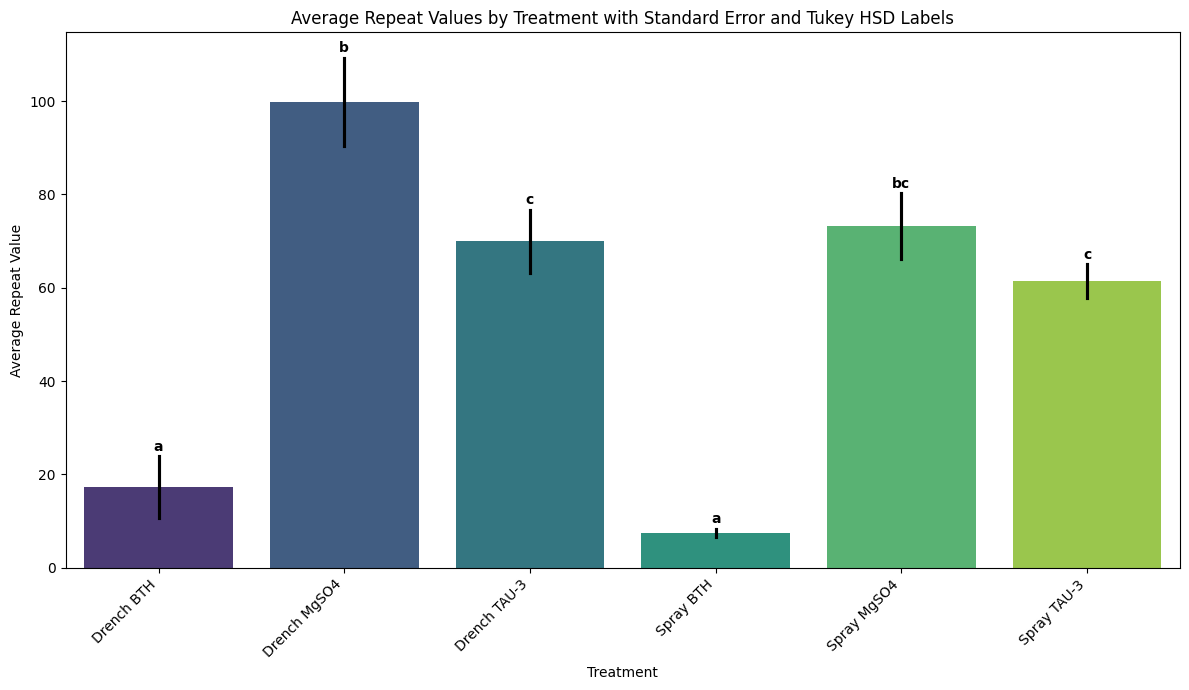

In [12]:
# Re-create the bar plot with alphabetical labels if generated
plt.figure(figsize=(12, 7))
sns.barplot(x='Treatment', y='Repeat_Value', data=df_melted, palette='viridis',
            errorbar='se',
            hue='Treatment', legend=False,
            err_kws={'color': 'black'},
            order=treatments) # Ensure bar order matches the sorted treatments for labels

# Add alphabetical labels if they exist
if 'Label' in df_melted.columns and not df_melted['Label'].eq('').all():
    # Get the unique treatments and their corresponding labels
    unique_treatments = df_melted[['Treatment', 'Label']].drop_duplicates().sort_values('Treatment')

    # Get the y-coordinates for placing labels (average of Repeat_Value + error bar height)
    # Calculate mean and standard error for each treatment
    means = df_melted.groupby('Treatment')['Repeat_Value'].mean()
    ses = df_melted.groupby('Treatment')['Repeat_Value'].sem() # Standard error of the mean

    # Find the maximum height for label placement (mean + se)
    label_heights = means + ses

    for i, treatment in enumerate(unique_treatments['Treatment']):
        label = unique_treatments[unique_treatments['Treatment'] == treatment]['Label'].iloc[0]
        height = label_heights[treatment]
        plt.text(i, height + 0.5, label, ha='center', va='bottom', fontsize=10, weight='bold')


plt.title('Average Repeat Values by Treatment with Standard Error and Tukey HSD Labels')
plt.xlabel('Treatment')
plt.ylabel('Average Repeat Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4165/2314052384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Treatment', y='Repeat_Value', data=df_melted, palette='viridis')


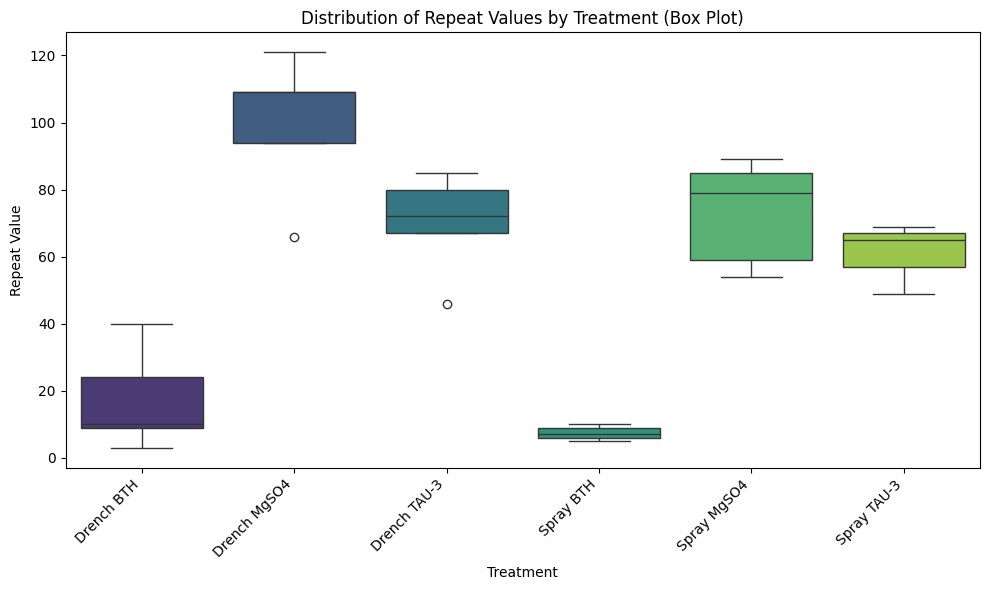

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Treatment', y='Repeat_Value', data=df_melted, palette='viridis')
plt.title('Distribution of Repeat Values by Treatment (Box Plot)')
plt.xlabel('Treatment')
plt.ylabel('Repeat Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()